# Modelling Galaxy Populations


In [1]:
from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import z_at_value
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from synthesizer.grid import Grid
from synthpop import GalaxyPopulation
from synthpop.models import Model, Default, Constant
from unyt import yr, Myr, Msun, Gyr, unyt_quantity, Mpc, dimensionless


## Initialisation

In [2]:
# load grid
grid = Grid("test_grid")

# load default model
model = Default()
model = Constant()

# Define the volume of the galaxy population
volume = 1E4 * Mpc**3

In [3]:

# Instantiate the galaxy population
galpop = GalaxyPopulation(
    minimum_stellar_mass=1E8*Msun, 
    maximum_stellar_mass=1E11*Msun, 
    volume=volume,
    model=model,
    grid=grid,
    cosmology=cosmo,
    redshift=0.0,
    random_seed=42)

print(galpop)




----------
SUMMARY OF PARAMETERISED STAR FORMATION HISTORY
<class 'synthesizer.parametric.sf_hist.Constant'>
min_age: 0 yr
max_age: 13786.885302009709 Myr
median age: 4999.50 Myr
mean age: 4999.50 Myr
----------

----------
SUMMARY OF PARAMETERISED METAL ENRICHMENT HISTORY
<class 'synthesizer.parametric.metal_dist.DeltaConstant'>
metallicity: None
log10metallicity: -2.5
----------

2.0012995897025785e+38 kg
+---------------------------------------------------------------------------------------------------------------+
|                                                     STARS                                                     |
+-----------------------------+---------------------------------------------------------------------------------+
| Attribute                   | Value                                                                           |
+-----------------------------+---------------------------------------------------------------------------------+
| component_type   

/Users/sw376/Dropbox/Research/projects/synthpop/venv/lib/python3.10/site-packages/unyt/array.py:1900: RuntimeWarning: divide by zero encountered in log10
  out_arr = func(np.asarray(inp), out=out_func, **kwargs)


----------
SUMMARY OF PARAMETERISED STAR FORMATION HISTORY
<class 'synthesizer.parametric.sf_hist.Constant'>
min_age: 0 yr
max_age: 13786.885302009709 Myr
median age: 4999.50 Myr
mean age: 4999.50 Myr
----------

----------
SUMMARY OF PARAMETERISED METAL ENRICHMENT HISTORY
<class 'synthesizer.parametric.metal_dist.DeltaConstant'>
metallicity: None
log10metallicity: -2.5
----------

2.0766893228579805e+38 kg
+---------------------------------------------------------------------------------------------------------------+
|                                                     STARS                                                     |
+-----------------------------+---------------------------------------------------------------------------------+
| Attribute                   | Value                                                                           |
+-----------------------------+---------------------------------------------------------------------------------+
| component_type   

## Useful methods and plots

### Galaxy stellar mass function

/Users/sw376/Dropbox/Research/projects/synthpop/src/synthpop/galaxy_populations.py:328: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


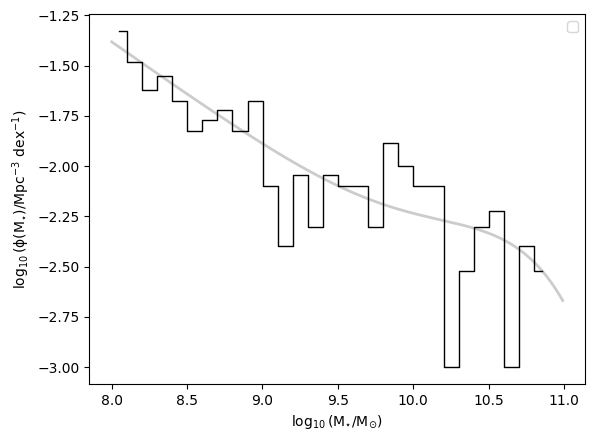

In [4]:
galpop.plot_stellar_mass_function()

### Dust attenuation

Because the chosen model predicts the dust attenuation experienced by individual galaxies, we can investigate how dust attenuation varies as a function of stellar mass. The figure below illustrates the predicted relationship between these two quantities.

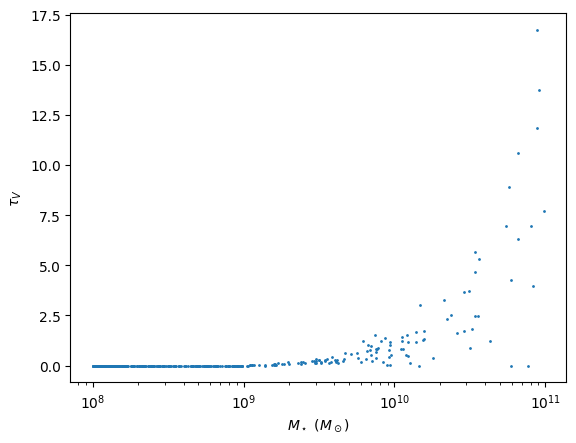

In [5]:
plt.scatter(galpop.surviving_masses.to("Msun"), galpop.tau_v, s=1)
plt.xscale('log')
plt.xlabel(r'$M_\star\ (M_\odot)$')
plt.ylabel(r'$\tau_V$')
plt.show()

### Star formation rate distribution function

/Users/sw376/Dropbox/Research/projects/synthpop/src/synthpop/galaxy_populations.py:355: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


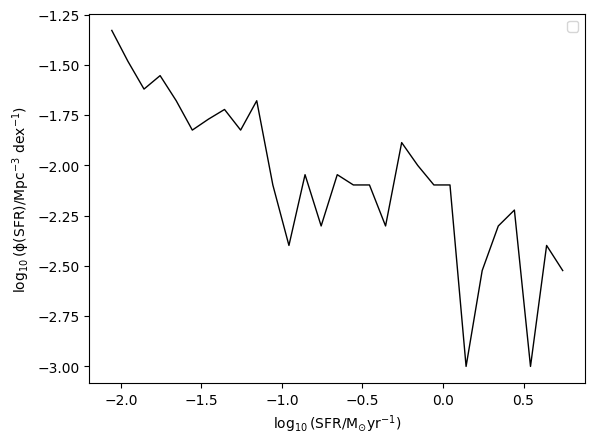

In [6]:
galpop.plot_star_formation_rate_distribution_function()

### Stellar mass vs. (specific) star formation rate 

/Users/sw376/Dropbox/Research/projects/synthpop/src/synthpop/galaxy_populations.py:400: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


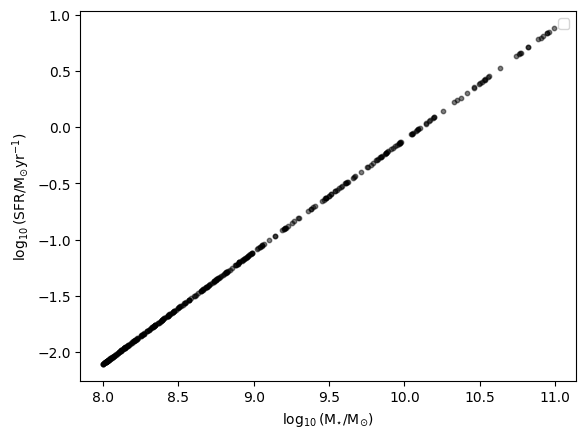

/Users/sw376/Dropbox/Research/projects/synthpop/src/synthpop/galaxy_populations.py:416: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


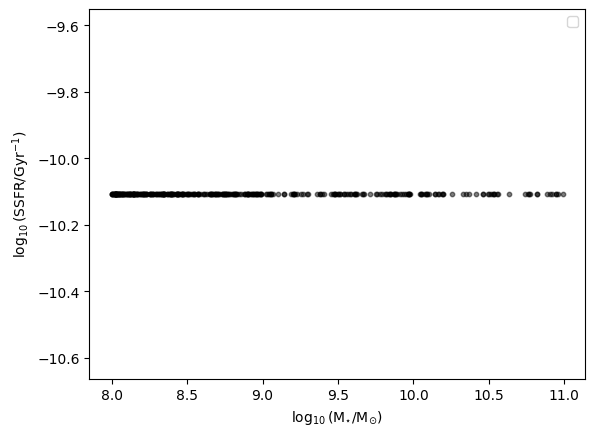

In [7]:
galpop.plot_sfr_vs_stellar_mass()
galpop.plot_ssfr_vs_stellar_mass()

### Star formation histories

Methods are also provided to plot either combined or individual star formation histories. By default, these display the stellar mass formed in each time bin; however, the star formation rate per bin can also be plotted as an alternative.

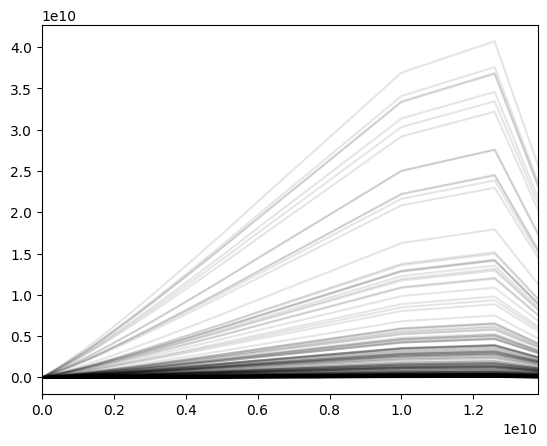

In [8]:

# Plot all star formation histories (SFHs) for the galaxy population. 
galpop.plot_sfhs(N='all')


# # Plot the combined SFH for the galaxy population. 
# galpop.plot_sfh()

# # Plot the combined star formation history using the rate.
# galpop.plot_sfh(rate=True)


## Combining galaxy populations

## Saving and loading GalaxyPopulation

The GalaxyPopulation class includes the functionality to dump as a pickle file and reload it later.

In [ ]:
galpop.save_to_pickle("galaxy_population.pkl")

del galpop

# Load the galaxy population from the pickle file
galpop_loaded = GalaxyPopulation.load_from_pickle("galaxy_population.pkl")
print(galpop_loaded)

## Project galaxy population to earlier time

In [9]:
# galpop_z1 = galpop.project_to_earlier_epoch(redshift=3.0)

# print(galpop)
# print(galpop_z1)

In [10]:

# galpop.plot_stellar_mass_function()
# print(galpop.age_of_the_universe)
# galpop_z1.plot_stellar_mass_function()
# print(galpop_z1.age_of_the_universe)